<a href="https://colab.research.google.com/github/purkutis/Samuel_INFO4670_SPRING2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [17]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [5]:
#Loading the dataset
from google.colab import files
files.upload()
df = pd.read_csv('car_purchase_data.csv')
df.head()

Saving car_purchase_data.csv to car_purchase_data.csv


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [93]:
#Please write the code here
X = df[['Age', 'Salary']]
Y = df['Purchased']

print('X Shape:', X.shape)
print('Y distributoin: \n', Y.value_counts())

X Shape: (400, 2)
Y distributoin: 
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [108]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.279, random_state=0, stratify = Y)

In [109]:
#Print test size and train size
print('X train shape:', X_train.shape)
print('X test shape:', X_test.shape)

X train shape: (288, 2)
X test shape: (112, 2)


### Step 4: Feature Scaling

In [110]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print('Scaling Complete.')

Scaling Complete.


### Step 5: Train Logistic Regression Model

In [111]:
classifier = LogisticRegression(solver='liblinear',class_weight={0: 1, 1: 2}, max_iter=1000)
classifier.fit(X_train, Y_train)
print('Training Complete.')

Training Complete.


### Step 6: Predict and Evaluate

In [112]:
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print('Accuracy:', accuracy)
print('Confusion Matrix:\n', confusion_matrix(Y_test, y_pred))
print('Classification Report:\n',classification_report(Y_test, y_pred))

Accuracy: 0.8303571428571429
Confusion Matrix:
 [[59 13]
 [ 6 34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.82      0.86        72
           1       0.72      0.85      0.78        40

    accuracy                           0.83       112
   macro avg       0.82      0.83      0.82       112
weighted avg       0.84      0.83      0.83       112



### Step 7: Visualization of Decision Regions

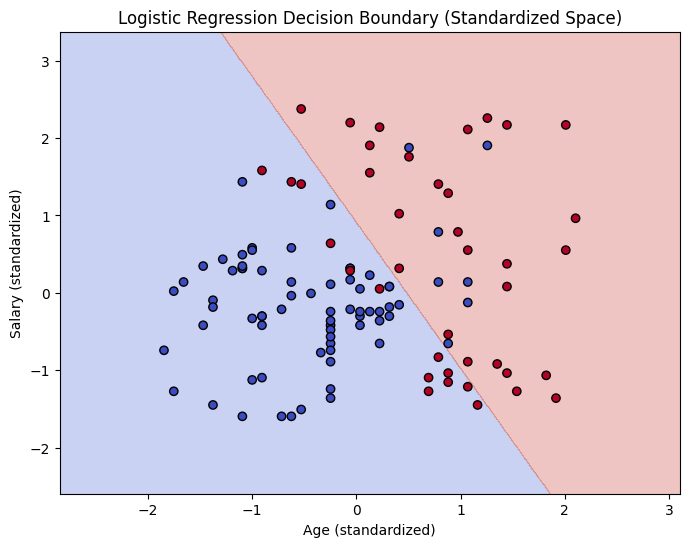

In [113]:
#Please write the code here
X_set, y_set = X_test[:, :2], Y_test.values
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train[:, :2], Y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)

Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Standardized Space)')
plt.xlabel('Age (standardized)')
plt.ylabel('Salary (standardized)')
plt.show()


## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

Ans #1: Logistic regression outputs, probabilities, but since it inputs a sigmoid curve in between it classifies with a cut off that we can choose while training the model.

Ans #2: Based on my model, population with middle age gradually moving to old age tend to buy the car. Furthermore, people with middle income to high income tend to buy the car.

Ans #3: Since, the .predict function that we used has a cut off of 0.5, it may not be the ideal cut off for binary classification. Sometimes, it may be 0.4 or 0.6.

Ans #4: I think to improve accuracy we can optimize the hyperparameter C, handle outlier effectively and interact the features like Age * Income. I wasn't quite confident on manipulating the hyperparamter in this assignment so I am hoping to learn that in futher weeks.
















































































































